# Section 1

In [163]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from datetime import datetime
from statistics import mean, stdev, log
from statsmodels.tsa.stattools import adfuller

In [164]:
f = open("top100coins.txt", "r")
lines = f.read().split("\n")
coins = lines[1::5]
coins_prices = {}
for coin in coins:
    data = yf.Ticker(coin).history(
        interval="1d", start=datetime(2023, 12, 1), end=datetime(2024, 12, 1)
    )
    
    if not data.empty:
        coins_prices[coin] = data.Close
coins_prices = pd.DataFrame(coins_prices)

$HYPE32196-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$USDS33039-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$RENDER-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$CBBTC32994-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$MOVE32452-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$LBTC33652-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$KAIA-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$SOLVBTC-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)


In [165]:
stationary_coins_data1 = []
for coin in coins_prices.columns:
    if adfuller(coins_prices[coin].dropna())[1] < 0.05:
        stationary_coins_data1.append(coin)

stationary_coins_data1 = coins_prices[stationary_coins_data1]

In [166]:
stationary_coins_data2 = []
for coin in coins_prices.columns:
    res = adfuller(coins_prices[coin].dropna())
    statistic_res = res[0]
    critical_val = res[4]["5%"]
    if statistic_res < critical_val:
        stationary_coins_data2.append(coin)

stationary_coins_data2 = coins_prices[stationary_coins_data2]

In [167]:
print("Stationary coins of first approach:")
for coin in stationary_coins_data1:
    print(coin)

print("Stationary coins of second approach:")
for coin in stationary_coins_data2:
    print(coin)


Stationary coins of first approach:
USDT-USD
USDC-USD
DAI-USD
FDUSD-USD
Stationary coins of second approach:
USDT-USD
USDC-USD
DAI-USD
FDUSD-USD


# Section 2

In [168]:
def Divide_Chunks(series: pd.DataFrame, column) -> list:
    different_chunks = []
    series = series.copy().reset_index(drop=True, inplace=False)
    len_series = len(series)
    while len_series > 1:
        temp = pd.DataFrame(
            {
                i: series.loc[i * len_series : (i + 1) * len_series - 1, column].values
                for i in range(len(series) // len_series)
            },
            index=[i for i in range(len_series)],
        )
        different_chunks.append(temp)
        len_series = len_series // 2
    return different_chunks

In [169]:
def Hurst_Exponent(series: pd.DataFrame, column):
    divided_chunks = Divide_Chunks(series, column)
    means = [chunk.apply(mean) for chunk in divided_chunks]
    stds = [chunk.apply(stdev) for chunk in divided_chunks]
    for index, chunk in enumerate(divided_chunks):
        chunk -= means[index]
    cumsum = [chunk.cumsum() for chunk in divided_chunks]
    r_n = [chunk.max() - chunk.min() for chunk in cumsum]
    for index, r in enumerate(r_n):
        r /= stds[index]
    mean_r = [r.mean() for r in r_n]
    log_r = []
    log_size = []
    for index, m_r in enumerate(mean_r):
        log_r.append(log(m_r))
        log_size.append(log(len(divided_chunks[index].index)))

    slope_intercept = np.polyfit(log_size, log_r, 1)
    return slope_intercept[0]

In [170]:
for coin in stationary_coins_data1:
    H = Hurst_Exponent(stationary_coins_data1, coin)
    print(f"for coin {coin}, H value is {H}")

for coin USDT-USD, H value is 0.8742905063020255
for coin USDC-USD, H value is 0.8511320306414738
for coin DAI-USD, H value is 0.8018268884393122
for coin FDUSD-USD, H value is 0.8008316802684409


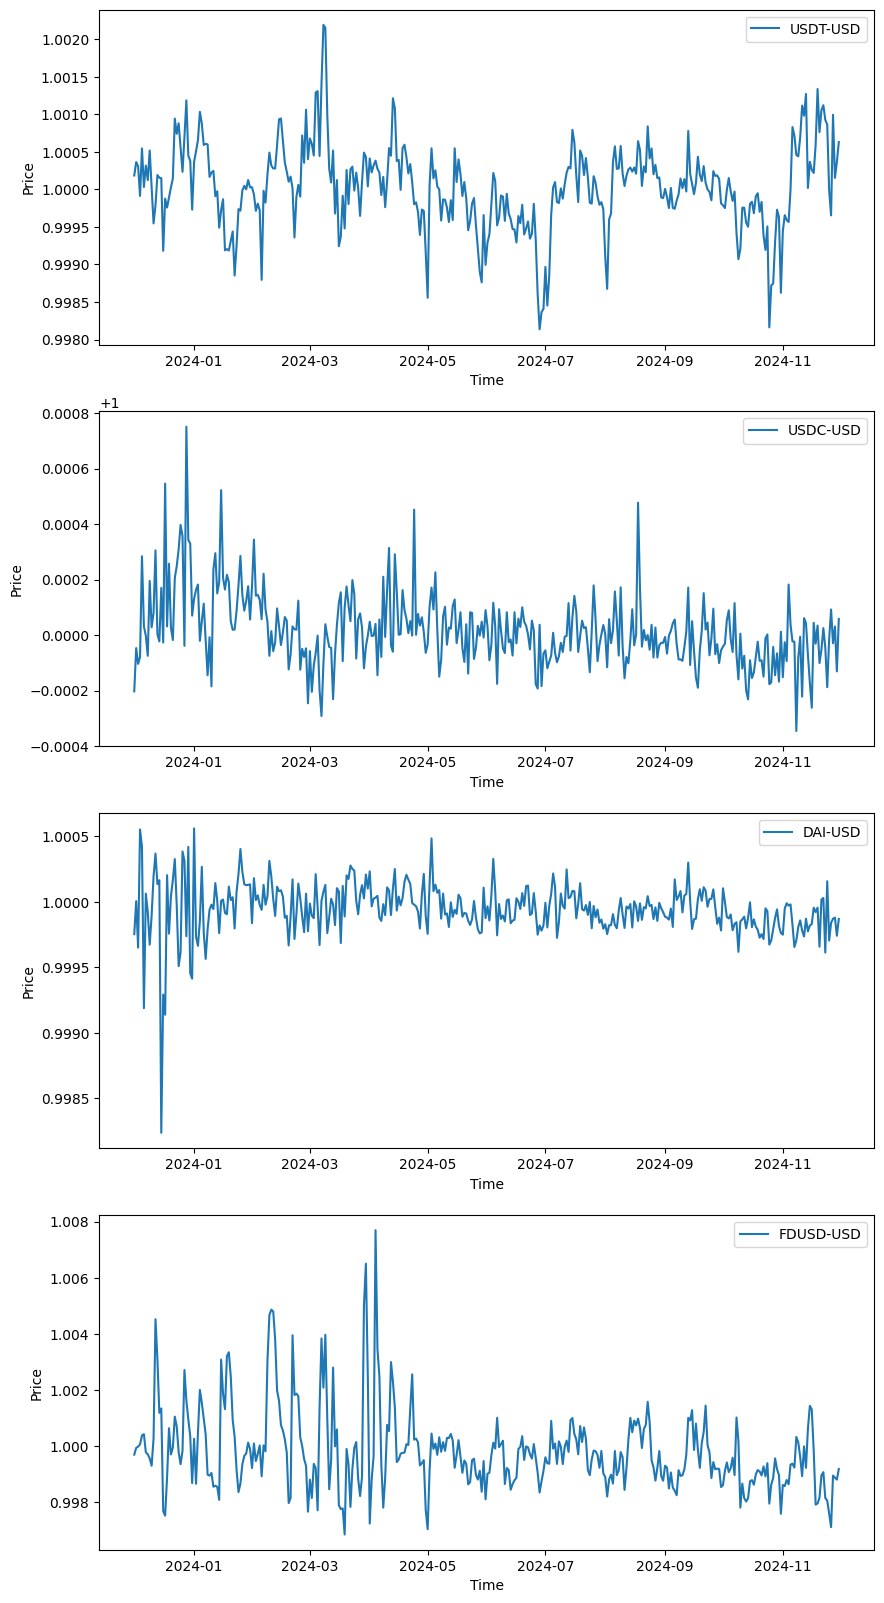

In [172]:
plt.figure(figsize=(10, 20))
for index, coin in enumerate(stationary_coins_data1):
    plt.subplot(4, 1, index + 1)
    plt.plot(stationary_coins_data1[coin], label = coin)
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()

plt.show()